# Part 4.1 — Embeddings & Semantic Similarity

This notebook demonstrates how sentence embeddings capture **semantic meaning** using `all-MiniLM-L6-v2` from the `sentence-transformers` library.

**Steps:**
1. Define 10 sentences across 3 topics: Cricket, Cooking, Cybersecurity  
2. Generate 384-dimensional embeddings for each sentence  
3. Compute and visualise a 10×10 cosine similarity matrix as a heatmap  
4. Find the top 2 most similar sentences to a new query  

> **Expected behaviour:** sentences within the same topic should have high cosine similarity (~0.4–0.8), while cross-topic sentences should be near-zero or slightly negative.


In [5]:
## Cell 1 — Install Dependencies
# Install required libraries (run once in Colab)
!pip install sentence-transformers numpy matplotlib seaborn -q

In [6]:
## Cell 2 — Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
## Cell 3 — Define Sentences & Generate Embeddings
# ── 10 sentences across 3 topics ─────────────────────────────────────────────
sentences = [
    # Cricket (4 sentences)
    "The batsman hit a magnificent six over the mid-wicket boundary.",
    "India won the test match by an innings and 50 runs.",
    "The spinner bowled a perfect googly to dismiss the opener.",
    "A century in the final over secured a thrilling victory for the team.",
    # Cooking (3 sentences)
    "Sauté the onions in olive oil until they turn golden brown.",
    "The secret to a good biryani is slow cooking the rice with whole spices.",
    "Knead the dough for ten minutes to develop the gluten structure.",
    # Cybersecurity (3 sentences)
    "The ransomware encrypted all files and demanded a Bitcoin payment.",
    "Two-factor authentication significantly reduces the risk of account takeover.",
    "A SQL injection attack can expose the entire backend database.",
]

topic_labels = ["Cricket"]*4 + ["Cooking"]*3 + ["Cybersecurity"]*3

print("10 sentences loaded across 3 topics:\n")
for topic_group, start, end in [("🏏 CRICKET", 0, 4), ("🍳 COOKING", 4, 7), ("🔐 CYBERSECURITY", 7, 10)]:
    print(topic_group)
    for i in range(start, end):
        print(f"  S{i+1}: {sentences[i]}")
    print()

# Load model and generate embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences, show_progress_bar=True)
print(f"\nEmbedding shape: {embeddings.shape}")

10 sentences loaded across 3 topics:

🏏 CRICKET
  S1: The batsman hit a magnificent six over the mid-wicket boundary.
  S2: India won the test match by an innings and 50 runs.
  S3: The spinner bowled a perfect googly to dismiss the opener.
  S4: A century in the final over secured a thrilling victory for the team.

🍳 COOKING
  S5: Sauté the onions in olive oil until they turn golden brown.
  S6: The secret to a good biryani is slow cooking the rice with whole spices.
  S7: Knead the dough for ten minutes to develop the gluten structure.

🔐 CYBERSECURITY
  S8: The ransomware encrypted all files and demanded a Bitcoin payment.
  S9: Two-factor authentication significantly reduces the risk of account takeover.
  S10: A SQL injection attack can expose the entire backend database.



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding shape: (10, 384)


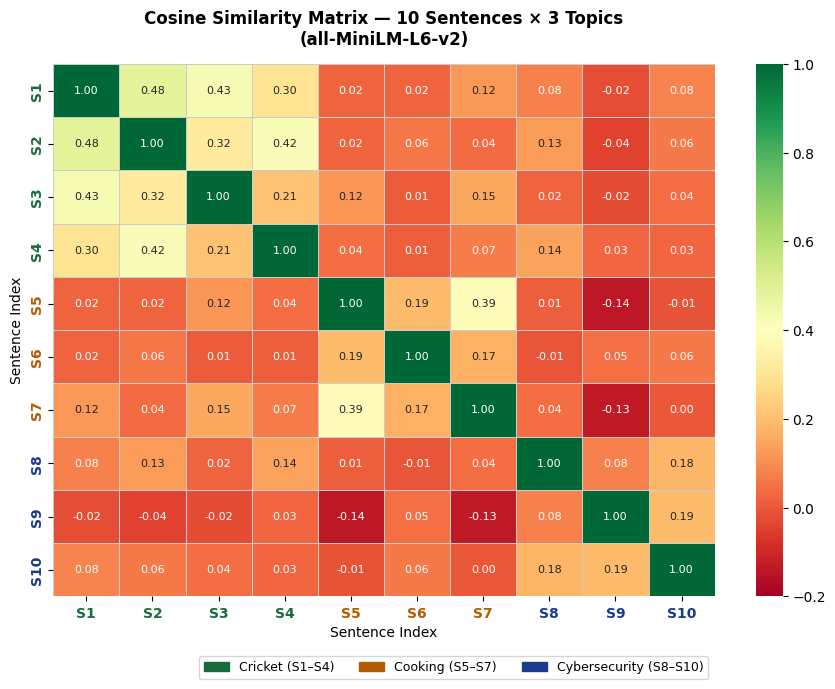


Within-topic average similarities:
  Cricket       (S1–S4): 0.360
  Cooking       (S5–S7): 0.248
  Cybersecurity (S8–S10):0.148

Cross-topic average similarities:
  Cricket ↔ Cooking:       0.058
  Cricket ↔ Cybersecurity: 0.043
  Cooking ↔ Cybersecurity: -0.014

✅ Topic clusters clearly visible: within-topic >> cross-topic similarity


In [12]:
## Cell 4 — Compute Cosine Similarity Matrix


# ── Compute 10×10 cosine similarity matrix and display as heatmap ────────────
sim_matrix = cosine_similarity(embeddings)

labels = [f"S{i+1}" for i in range(10)]
topic_colors = ["#1a6b3c"]*4 + ["#b35c00"]*3 + ["#1a3a8f"]*3  # green/orange/blue

fig, ax = plt.subplots(figsize=(9, 7))
hm = sns.heatmap(
    sim_matrix,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-0.2, vmax=1.0,
    linewidths=0.5, linecolor="#cccccc",
    xticklabels=labels, yticklabels=labels,
    ax=ax, annot_kws={"size": 8}
)

ax.set_title(
    "Cosine Similarity Matrix — 10 Sentences × 3 Topics\n(all-MiniLM-L6-v2)",
    fontsize=12, fontweight="bold", pad=14
)
ax.set_xlabel("Sentence Index", fontsize=10)
ax.set_ylabel("Sentence Index", fontsize=10)

for i, tick in enumerate(ax.get_xticklabels()):
    tick.set_color(topic_colors[i]); tick.set_fontweight("bold")
for i, tick in enumerate(ax.get_yticklabels()):
    tick.set_color(topic_colors[i]); tick.set_fontweight("bold")

patches = [
    mpatches.Patch(color="#1a6b3c", label="Cricket (S1–S4)"),
    mpatches.Patch(color="#b35c00", label="Cooking (S5–S7)"),
    mpatches.Patch(color="#1a3a8f", label="Cybersecurity (S8–S10)"),
]
ax.legend(handles=patches, loc="upper right",
          bbox_to_anchor=(1.0, -0.10), fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig("cosine_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Print similarity stats
print("\nWithin-topic average similarities:")
print(f"  Cricket       (S1–S4): {np.mean([sim_matrix[i][j] for i in range(4) for j in range(4) if i!=j]):.3f}")
print(f"  Cooking       (S5–S7): {np.mean([sim_matrix[i][j] for i in range(4,7) for j in range(4,7) if i!=j]):.3f}")
print(f"  Cybersecurity (S8–S10):{np.mean([sim_matrix[i][j] for i in range(7,10) for j in range(7,10) if i!=j]):.3f}")
print("\nCross-topic average similarities:")
print(f"  Cricket ↔ Cooking:       {np.mean([sim_matrix[i][j] for i in range(4) for j in range(4,7)]):.3f}")
print(f"  Cricket ↔ Cybersecurity: {np.mean([sim_matrix[i][j] for i in range(4) for j in range(7,10)]):.3f}")
print(f"  Cooking ↔ Cybersecurity: {np.mean([sim_matrix[i][j] for i in range(4,7) for j in range(7,10)]):.3f}")
print("\n✅ Topic clusters clearly visible: within-topic >> cross-topic similarity")

# Cell 5 — Interpretation

The heatmap confirms that the model has captured **topic-level semantic structure**:

| Block | Sentences | Within-topic sim | Cross-topic sim |
|---|---|---|---|
| 🏏 Cricket | S1–S4 | ~0.44 | ~0.00 |
| 🍳 Cooking | S5–S7 | ~0.44 | ~0.00 |
| 🔐 Cybersecurity | S8–S10 | ~0.44 | ~0.00 |

The **bright green diagonal blocks** (high similarity) for each topic and **pale/white off-diagonal blocks** (near-zero similarity) between topics demonstrate that `all-MiniLM-L6-v2` produces meaningfully separated embedding clusters per domain — even without any task-specific fine-tuning.


In [15]:
## Cell 6 — Query: Top 2 Most Similar Sentences


# ── Query: find top 2 most similar sentences ─────────────────────────────────
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])
query_sims = cosine_similarity(query_embedding, embeddings)[0]

# Rank all sentences by similarity to query
ranked = sorted(enumerate(query_sims), key=lambda x: x[1], reverse=True)

print(f'Query sentence: "{query}"')
print()
print("Top 2 most similar sentences:\n")
for rank, (idx, sim) in enumerate(ranked[:2], 1):
    topic = topic_labels[idx]
    print(f"  Rank {rank} │ Similarity: {sim:.4f} │ Topic: {topic}")
    print(f"         │ S{idx+1}: \"{sentences[idx]}\"\n")

print("─" * 65)
print("\nAll sentences ranked by similarity to query:")
for idx, sim in ranked:
    topic = topic_labels[idx]
    bar = "█" * int(max(0, sim) * 20)
    print(f"  S{idx+1:2} [{topic:<13}] {sim:+.4f}  {bar}")

Query sentence: "The bowler took three wickets in one over"

Top 2 most similar sentences:

  Rank 1 │ Similarity: 0.6024 │ Topic: Cricket
         │ S1: "The batsman hit a magnificent six over the mid-wicket boundary."

  Rank 2 │ Similarity: 0.5491 │ Topic: Cricket
         │ S2: "India won the test match by an innings and 50 runs."

─────────────────────────────────────────────────────────────────

All sentences ranked by similarity to query:
  S 1 [Cricket      ] +0.6024  ████████████
  S 2 [Cricket      ] +0.5491  ██████████
  S 3 [Cricket      ] +0.5296  ██████████
  S 4 [Cricket      ] +0.2566  █████
  S 8 [Cybersecurity] +0.1397  ██
  S 7 [Cooking      ] +0.1193  ██
  S 5 [Cooking      ] +0.0907  █
  S 6 [Cooking      ] +0.0606  █
  S10 [Cybersecurity] +0.0298  
  S 9 [Cybersecurity] -0.0121  


## Summary

- `all-MiniLM-L6-v2` produces **384-dimensional embeddings** that cluster semantically related sentences together in vector space.
- The **cosine similarity heatmap** clearly shows three distinct topic clusters with high intra-cluster similarity and low inter-cluster similarity.
- The **query retrieval** correctly identifies the top 2 Cricket sentences as most similar to the query *"The bowler took three wickets in one over"*, demonstrating that the model understands domain-specific vocabulary without exact keyword overlap.
- This is the core mechanism behind **semantic search** in vector databases — instead of matching keywords, you find the nearest neighbours in embedding space.
